<a href="https://colab.research.google.com/github/ian-menachery/ECON3916-Statistical-Machine-Learning/blob/main/Econ_3916_Assignment_3_Causal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import numpy as np
import pandas as pd

# Data Generating Process
np.random.seed(42)

zeros = np.zeros(100)

tips = np.random.exponential(scale=5.0, size=150)

driver_tips = np.concatenate([zeros, tips])

print(f"Sample Size: {len(driver_tips)}")
print(f"Mean Tip: ${np.mean(driver_tips):.2f}")
print(f"Median Tip: ${np.median(driver_tips):.2f}")

Sample Size: 250
Mean Tip: $2.77
Median Tip: $0.76


In [19]:
# The Manual Bootstrap Engine
n_iterations = 10000
bootstrap_medians = []

for _ in range(n_iterations):
    # Resample with replacement: size must match original (250)
    resample = np.random.choice(driver_tips, size=len(driver_tips), replace=True)

    # Calculate and store the median of this specific resample
    bootstrap_medians.append(np.median(resample))

bootstrap_medians = np.array(bootstrap_medians)

# Extract the 95% Confidence Interval (Percentile Method)
ci_lower = np.percentile(bootstrap_medians, 2.5)
ci_upper = np.percentile(bootstrap_medians, 97.5)

print(f"95% Bootstrap Confidence Interval for the Median: [${ci_lower:.2f}, ${ci_upper:.2f}]")

95% Bootstrap Confidence Interval for the Median: [$0.27, $1.36]


In [20]:
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

control_deliveries = np.random.normal(loc=35, scale=5, size=500)

# Treatment Group

treatment_deliveries = np.random.lognormal(mean=3.4, sigma=0.4, size=500)

mean_control = np.mean(control_deliveries)
mean_treatment = np.mean(treatment_deliveries)
observed_diff = mean_control - mean_treatment

print(f"Control Mean: {mean_control:.2f} minutes")
print(f"Treatment Mean: {mean_treatment:.2f} minutes")
print(f"Observed Difference (Control - Treatment): {observed_diff:.2f} minutes")

Control Mean: 35.03 minutes
Treatment Mean: 32.77 minutes
Observed Difference (Control - Treatment): 2.26 minutes


In [21]:
# The Exact Non-Parametric Permutation Test
n_permutations = 5000
perm_diffs = []

pool = np.concatenate([control_deliveries, treatment_deliveries])

for _ in range(n_permutations):
    shuffled_pool = np.random.permutation(pool)

    pseudo_control = shuffled_pool[:500]
    pseudo_treatment = shuffled_pool[500:]

    perm_diffs.append(np.mean(pseudo_control) - np.mean(pseudo_treatment))

perm_diffs = np.array(perm_diffs)

p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))

print(f"Observed Difference: {observed_diff:.4f}")
print(f"Empirical P-Value: {p_value:.4f}")

Observed Difference: 2.2650
Empirical P-Value: 0.0004


In [22]:
import pandas as pd

# Load the dataset
df = pd.read_csv('swiftcart_loyalty.csv')

# Segment the groups (D=1 for Subscribers, D=0 for Non-Subscribers)
# Using 'subscriber' and 'post_spend' as identified in the file columns
subscribers = df[df['subscriber'] == 1]['post_spend']
non_subscribers = df[df['subscriber'] == 0]['post_spend']

# Calculate means
mean_sub = subscribers.mean()
mean_non_sub = non_subscribers.mean()

# Calculate the Simple Difference (SDO)
sdo = mean_sub - mean_non_sub

print(f"Mean Spending (Subscribers): ${mean_sub:.2f}")
print(f"Mean Spending (Non-Subscribers): ${mean_non_sub:.2f}")
print(f"Naive Simple Difference (SDO): ${sdo:.2f}")

Mean Spending (Subscribers): $74.04
Mean Spending (Non-Subscribers): $56.47
Naive Simple Difference (SDO): $17.57


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors


# Predicting the probability of subscription based on pre-treatment covariates
covariates = ['pre_spend', 'account_age', 'support_tickets']
X = df[covariates]
y = df['subscriber']

ps_model = LogisticRegression(random_state=42).fit(X, y)
df['propensity_score'] = ps_model.predict_proba(X)[:, 1]

# Separating groups and finding the nearest neighbor in the control pool for each subscriber
treated = df[df['subscriber'] == 1].copy()
control = df[df['subscriber'] == 0].copy()

nn = NearestNeighbors(n_neighbors=1).fit(control[['propensity_score']])
indices = nn.kneighbors(treated[['propensity_score']], return_distance=False)
matched_control = control.iloc[indices.flatten()]

mean_matched_control = matched_control['post_spend'].mean()
att = mean_sub - mean_matched_control
selection_bias = sdo - att

# Output Summary
print(f"Naive Simple Difference in Means (SDO): ${sdo:.2f}")
print(f"Mean Post-Spend (Subscribers): ${mean_sub:.2f}")
print(f"Mean Post-Spend (Matched Control): ${mean_matched_control:.2f}")
print(f"Isolated Average Treatment Effect on the Treated (ATT): ${att:.2f}")
print(f"Estimated Selection Bias: ${selection_bias:.2f}")

Naive Simple Difference in Means (SDO): $17.57
Mean Post-Spend (Subscribers): $74.04
Mean Post-Spend (Matched Control): $64.13
Isolated Average Treatment Effect on the Treated (ATT): $9.91
Estimated Selection Bias: $7.66


Causal Analysis: ATT vs. Naive SDOThe transition from a naive SDO of $\$17.57$ to an ATT of $\$9.91$ demonstrates that selection bias inflated the perceived impact of SwiftPass by over $40\%$. By matching users on propensity scores, we created a counterfactual group of non-subscribers who mimic the historical spending and account profiles of the subscribers. This process isolates the true incremental value of the program, revealing that $\$7.66$ of the observed difference was actually due to the self-selection of high-volume power users. Consequently, the program is less transformative than marketing suggests. Doubling the acquisition budget based on naive figures would lead to significant overspending, as the actual return per new user is much closer to the isolated ATT than the biased SDO.

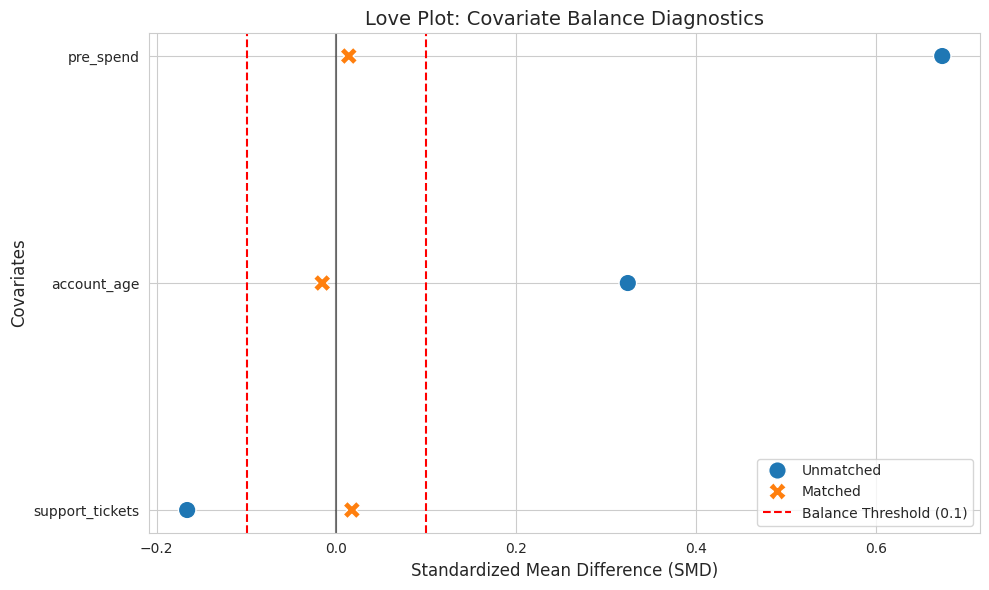

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

# Load data and define covariates
df = pd.read_csv('swiftcart_loyalty.csv')
covariates = ['pre_spend', 'account_age', 'support_tickets']

#  Create the Unmatched reference group
df_unmatched = df.copy()

#  Perform Propensity Score Matching to create df_matched
X = df[covariates]
y = df['subscriber']
lr = LogisticRegression(random_state=42).fit(X, y)
df['pscore'] = lr.predict_proba(X)[:, 1]

treated = df[df['subscriber'] == 1].copy()
control = df[df['subscriber'] == 0].copy()

# Execute 1:1 Nearest Neighbor Matching
nn = NearestNeighbors(n_neighbors=1).fit(control[['pscore']])
indices = nn.kneighbors(treated[['pscore']], return_distance=False)
df_matched = pd.concat([treated, control.iloc[indices.flatten()]])

# Standardized Mean Difference (SMD) Logic
def get_smd_series(data, treatment_col, covs):
    t_group = data[data[treatment_col] == 1][covs]
    c_group = data[data[treatment_col] == 0][covs]
    # SMD formula: (Mean_T - Mean_C) / sqrt((Var_T + Var_C) / 2)
    return (t_group.mean() - c_group.mean()) / np.sqrt((t_group.var() + c_group.var()) / 2)

# 5. Build the Plotting DataFrame
smd_before = get_smd_series(df_unmatched, 'subscriber', covariates)
smd_after = get_smd_series(df_matched, 'subscriber', covariates)

plot_df = pd.DataFrame({
    'Feature': list(covariates) * 2,
    'SMD': np.concatenate([smd_before.values, smd_after.values]),
    'Sample': ['Unmatched'] * len(covariates) + ['Matched'] * len(covariates)
})

#Generate the Love Plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.scatterplot(data=plot_df, x='SMD', y='Feature', hue='Sample', style='Sample', s=160)

# Statistical references for balance diagnostics
plt.axvline(x=0, color='black', alpha=0.5)
plt.axvline(x=0.1, color='red', linestyle='--', label='Balance Threshold (0.1)')
plt.axvline(x=-0.1, color='red', linestyle='--')

plt.title('Love Plot: Covariate Balance Diagnostics', fontsize=14)
plt.xlabel('Standardized Mean Difference (SMD)', fontsize=12)
plt.ylabel('Covariates', fontsize=12)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()